In [1]:
# Utilities

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, f1_score, hamming_loss
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

In [2]:
df = pd.read_csv("CleanDataset.csv")
df.head()

,Unnamed: 0,doc_id,abstract,body_text,asjc,authors,openaccess,pub_year,subjareas,title,...,body_clean,abstract_clean,body_tokenized,body_tok=2,abstract_tokenized,abstract_tok=2,body_lemmatized,abstract_lemmatized,preprocessed_body,preprocessed_abstract
0,0,S2352340916308101,The data presented here were originally collec...,"However, a key limitation of this approach usi...",1000,"Juan Miguel Rodriguez Lopez, Katharina Heider,...",Full,2017,MULT,Human and remote sensing data to investigate t...,...,however key limitation approach using arcgis c...,data presented originally collected frontiers ...,"['however', 'key', 'limitation', 'approach', '...","[('however', 'key'), ('key', 'limitation'), ('...","['data', 'presented', 'originally', 'collected...","[('data', 'presented'), ('presented', 'origina...","['however', 'key', 'limitation', 'approach', '...","['data', 'present', 'originally', 'collect', '...",however key limitation approach use arcgis cos...,data present originally collect frontier urban...
1,1,S2352340916300440,An easy method that combined gel casting and p...,The compressive stress–strain curves of carbon...,1000,"Yao Yao, Fei Chen, Xi Chen, Qiang Shen, Lianme...",Full,2016,MULT,Data of microstructure and mechanical properti...,...,compressive stressstrain curves carbon foams p...,easy method combined gel casting physical foam...,"['compressive', 'stressstrain', 'curves', 'car...","[('compressive', 'stressstrain'), ('stressstra...","['easy', 'method', 'combined', 'gel', 'casting...","[('easy', 'method'), ('method', 'combined'), (...","['compressive', 'stressstrain', 'curve', 'carb...","['easy', 'method', 'combine', 'gel', 'cast', '...",compressive stressstrain curve carbon foam plo...,easy method combine gel cast physical foam use...
2,2,S2352340919302719,The survey data presented in this article prov...,The surveys questions varied with a minimum of...,1000,"Ladina Knapp, Esther Bravin, Robert Finger",Full,2019,MULT,Data on Swiss fruit and wine growers’ manageme...,...,surveys questions varied minimum questions max...,survey data presented provides information ris...,"['surveys', 'questions', 'varied', 'minimum', ...","[('surveys', 'questions'), ('questions', 'vari...","['survey', 'data', 'presented', 'provides', 'i...","[('survey', 'data'), ('data', 'presented'), ('...","['survey', 'question', 'vary', 'minimum', 'que...","['survey', 'data', 'present', 'provide', 'info...",survey question vary minimum question maximum ...,survey data present provide information risk m...
3,6,S2352340918308400,Initial participants were 79 children who were...,Ability estimates were generated using a Rasch...,1000,"Bethany Rittle-Johnson, Erica L. Zippert, Kath...",Full,2018,MULT,"Data on preschool children׳s math, patterning,...",...,ability estimates generated using rasch model ...,initial participants children recruited six pr...,"['ability', 'estimates', 'generated', 'using',...","[('ability', 'estimates'), ('estimates', 'gene...","['initial', 'participants', 'children', 'recru...","[('initial', 'participants'), ('participants',...","['ability', 'estimate', 'generate', 'use', 'ra...","['initial', 'participant', 'child', 'recruit',...",ability estimate generate use rasch model lapl...,initial participant child recruit six preschoo...
4,7,S2352340916303766,"The data presented here comprise clinical, neu...",The goal was to eliminate the d׳s with exactly...,1000,"Catherine M. Sweeney-Reed, Tino Zaehle, Jürgen...",Full,2016,MULT,"Clinical, neuropsychological, and pre-stimulus...",...,goal eliminate ds exactly two marks top two bo...,data presented comprise clinical neuropsycholo...,"['goal', 'eliminate', 'ds', 'exactly', 'two', ...","[('goal', 'eliminate'), ('eliminate', 'ds'), (...","['data', 'presented', 'comprise', 'clinical', ...","[('data', 'presented'), ('presented', 'compris...","['goal', 'eliminate', 'd', 'exactly', 'two', '...","['data', 'present', 'comprise', 'clinical', 'n...",goal eliminate d exactly two mark top two bott

In [3]:
#subjareas 
#asjc
print(df["subjareas"].value_counts().to_string())

subjareas
MEDI                                  3127
BIOC                                  1848
ENVI                                  1298
BIOC, MEDI                            1083
IMMU, MEDI                            1073
EART                                  1043
NEUR                                  1001
PHAR                                   910
MEDI, NEUR                             903
AGRI                                   805
PHYS                                   765
ENGI, MATE                             739
BIOC, IMMU, MEDI, VETE                 733
MATE                                   608
AGRI, ENVI                             598
ENGI, MATE, PHYS                       537
NEUR, PSYC                             524
BIOC, HEAL                             504
AGRI, BIOC                             503
COMP                                   478
ARTS, SOCI                             462
ENER, ENGI, ENVI                       447
BIOC, PHAR                             427
E

In [4]:
from sklearn.preprocessing import MultiLabelBinarizer

df["labels_list"] = df["subjareas"].apply(
    lambda x: [label.strip() for label in x.split(",")]
)

mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df["labels_list"])

labels = mlb.classes_
print(labels)
print(y.shape)

['AGRI' 'ARTS' 'BIOC' 'BUSI' 'CENG' 'CHEM' 'COMP' 'DECI' 'DENT' 'EART'
 'ECON' 'ENER' 'ENGI' 'ENVI' 'HEAL' 'IMMU' 'MATE' 'MATH' 'MEDI' 'MULT'
 'NEUR' 'NURS' 'PHAR' 'PHYS' 'PSYC' 'SOCI' 'VETE']
(38711, 27)


MEDI    8930
BIOC    8196
ENVI    6166
ENGI    5849
AGRI    3942
MATE    3918
PHYS    3604
SOCI    3553
NEUR    3255
IMMU    3168
COMP    2919
ENER    2796
EART    2743
CHEM    2703
PHAR    2205
CENG    2139
PSYC    1774
MATH    1346
ECON    1059
ARTS    1007
BUSI     984
VETE     962
HEAL     750
DECI     522
NURS     301
MULT     194
DENT      43
dtype: int64


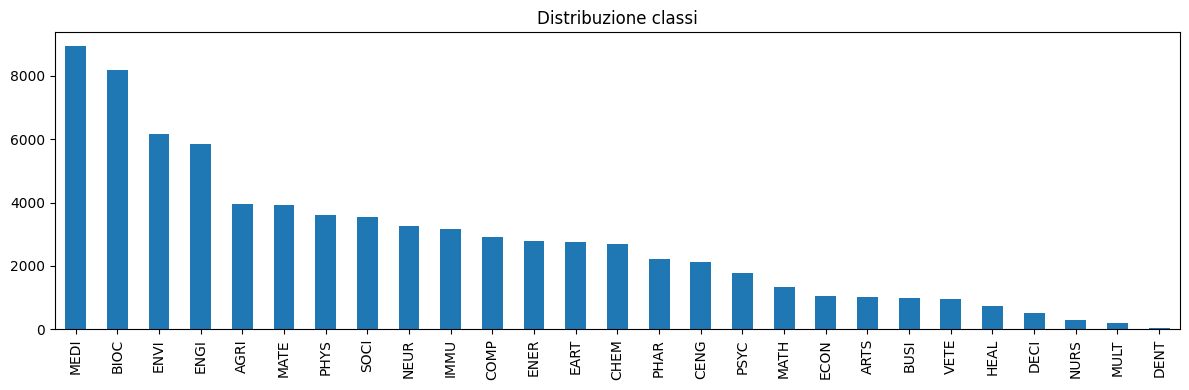

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

label_counts = pd.Series(y.sum(axis=0), index=labels).sort_values(ascending=False)
print(label_counts)

label_counts.plot(kind="bar", figsize=(12, 4))
plt.title("Distribuzione classi")
plt.tight_layout()
plt.show()

In [6]:
label_mapping = {
    "VETE": "MEDI", "HEAL": "MEDI", "DENT": "MEDI", "NURS": "MEDI",
    "ECON": "SOCI", "ARTS": "SOCI", "BUSI": "SOCI", "DECI": "SOCI",
    "MATH": "MULT",
}

def remap_labels(label_list):
    remapped = [label_mapping.get(l, l) for l in label_list]
    return list(set(remapped))

df["labels_remapped"] = df["labels_list"].apply(remap_labels)

mlb_18 = MultiLabelBinarizer()
y_18 = mlb_18.fit_transform(df["labels_remapped"])

labels_18 = mlb_18.classes_
print(f"Classi: {len(labels_18)}")
print(labels_18)

Classi: 18
['AGRI' 'BIOC' 'CENG' 'CHEM' 'COMP' 'EART' 'ENER' 'ENGI' 'ENVI' 'IMMU'
 'MATE' 'MEDI' 'MULT' 'NEUR' 'PHAR' 'PHYS' 'PSYC' 'SOCI']


MEDI    9885
BIOC    8196
ENVI    6166
ENGI    5849
SOCI    5180
AGRI    3942
MATE    3918
PHYS    3604
NEUR    3255
IMMU    3168
COMP    2919
ENER    2796
EART    2743
CHEM    2703
PHAR    2205
CENG    2139
PSYC    1774
MULT    1540
dtype: int64


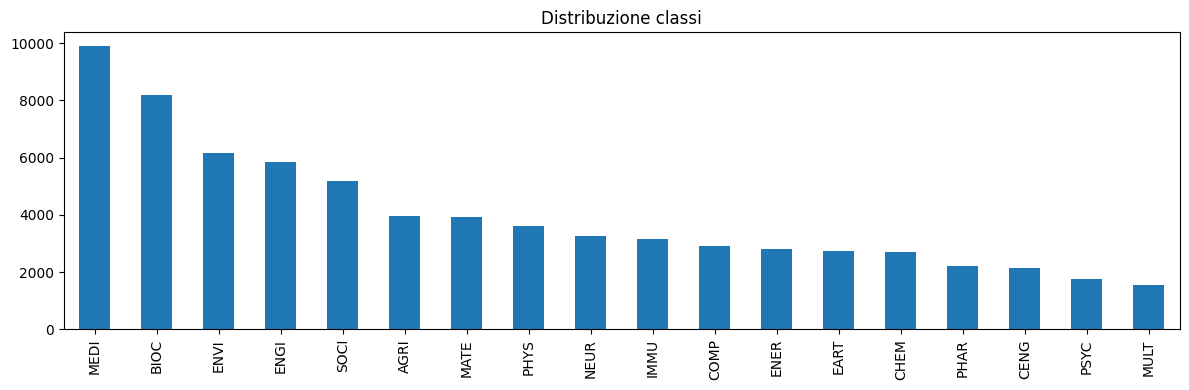

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

labels_18 = pd.Series(y_18.sum(axis=0), index=labels_18).sort_values(ascending=False)
print(labels_18)

labels_18.plot(kind="bar", figsize=(12, 4))
plt.title("Distribuzione classi")
plt.tight_layout()
plt.show()

In [8]:
def build_text(abstract, body, total=500):
    abs_words = str(abstract).split()
    body_words = str(body).split()
    
    abs_take = min(200, len(abs_words))
    body_take = total - abs_take
    
    return " ".join(abs_words[:abs_take]) + " " + " ".join(body_words[:body_take])

df["text"] = df.apply(
    lambda row: build_text(row["preprocessed_abstract"], row["preprocessed_body"]),
    axis=1
)

In [9]:
X = df["text"].astype(str).tolist()
y_18 = np.asarray(y_18, dtype=np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_18, test_size=0.3, random_state=42, shuffle=True
)

In [10]:
def tokenize(text):
    return text.split()

counter = Counter()
for text in X_train:
    counter.update(tokenize(text))

vocab = {"<PAD>": 0, "<UNK>": 1}
min_freq = 5
for word, freq in counter.items():
    if freq >= min_freq:
        vocab[word] = len(vocab)

vocabulary_size = len(vocab)
print("Vocabulary size:", vocabulary_size)

Vocabulary size: 67522


In [11]:
lengths = df["text"].str.split().str.len()
lengths.describe()

count    38711.000000
mean       498.958436
std         10.890650
min        167.000000
25%        500.000000
50%        500.000000
75%        500.000000
max        500.000000
Name: text, dtype: float64

In [12]:
max_len = 500

def encode_text(text):
    tokens = tokenize(text)
    ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    ids = ids[:max_len]
    return torch.tensor(ids, dtype=torch.long)

In [13]:
class ArticleDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = encode_text(self.texts[idx])
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

def collate_fn(batch):
    texts, labels = zip(*batch)
    texts = pad_sequence(texts, batch_first=True, padding_value=vocab["<PAD>"])
    labels = torch.stack(labels)
    return texts, labels

In [14]:
from sklearn.model_selection import train_test_split
from torch.utils.data import WeightedRandomSampler

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Calcolo pesi per le 18 classi su y_train
label_freq = y_train.sum(axis=0)
label_weights = 1.0 / np.where(label_freq == 0, 1, label_freq)  # evita divisione per zero
label_weights = label_weights / label_weights.sum()

# Peso per ogni sample = somma dei pesi delle sue label
train_sample_weights = y_train.dot(label_weights)

sampler = WeightedRandomSampler(
    weights=torch.tensor(train_sample_weights, dtype=torch.float),
    num_samples=len(train_sample_weights),
    replacement=True
)

batch_size = 1024

train_dataset = ArticleDataset(X_train, y_train)
val_dataset = ArticleDataset(X_val, y_val)
test_dataset = ArticleDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [15]:
class LSTMMultilabelClassifier(nn.Module):
    def __init__(self, vocabulary_size, embedding_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocabulary_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
            num_layers=2,
            dropout=0.2
        )
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        hidden = self.dropout(hidden)
        return self.fc(hidden)

In [16]:
device = torch.device("mps") # torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMMultilabelClassifier(
    vocabulary_size=vocabulary_size,
    embedding_dim=100,
    hidden_dim=128,
    output_dim=len(labels_18)
).to(device)

# pos_weight per BCEWithLogitsLoss: penalizza classi rare
pos_weight = torch.tensor(
    (len(y_train) - y_train.sum(axis=0)) / np.where(y_train.sum(axis=0) == 0, 1, y_train.sum(axis=0)),
    dtype=torch.float
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print(model)

LSTMMultilabelClassifier(
  (embedding): Embedding(67522, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=256, out_features=18, bias=True)
)


In [25]:
from tqdm import tqdm
from sklearn.metrics import f1_score

epochs = 100
train_losses, val_losses, train_f1s, val_f1s = [], [], [], []

print("Train...")

for epoch in range(epochs):
    model.train()
    total_loss = 0
    all_preds, all_targets = [], []

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

    for texts, targets in train_bar:
        texts = texts.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(targets.cpu().numpy())

        train_bar.set_postfix(loss=f"{total_loss/len(train_loader):.4f}")

    avg_loss = total_loss / len(train_loader)
    avg_f1 = f1_score(np.vstack(all_targets), np.vstack(all_preds), average="micro", zero_division=0)
    train_losses.append(avg_loss)
    train_f1s.append(avg_f1)

    # Validation
    model.eval()
    val_loss = 0
    val_preds, val_targets = [], []

    with torch.no_grad():
        for texts, targets in val_loader:
            texts = texts.to(device)
            targets = targets.to(device)
            outputs = model(texts)
            val_loss += criterion(outputs, targets).item()
            preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
            val_preds.append(preds)
            val_targets.append(targets.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    avg_val_f1 = f1_score(np.vstack(val_targets), np.vstack(val_preds), average="micro", zero_division=0)
    val_losses.append(avg_val_loss)
    val_f1s.append(avg_val_f1)

    print(f"Epoch {epoch+1}/{epochs} - loss: {avg_loss:.4f} - f1: {avg_f1:.4f} - val_loss: {avg_val_loss:.4f} - val_f1: {avg_val_f1:.4f}")

Train...


Epoch 1/100 - loss: 1.4135 - f1: 0.2260 - val_loss: 1.2276 - val_f1: 0.1829


Epoch 2/100 - loss: 1.2460 - f1: 0.2904 - val_loss: 1.0668 - val_f1: 0.2729


Epoch 3/100 - loss: 1.0857 - f1: 0.3704 - val_loss: 1.0241 - val_f1: 0.3004


Epoch 4/100 - loss: 1.0030 - f1: 0.4065 - val_loss: 0.9328 - val_f1: 0.3442


...

Epoch 96/100 - loss: 0.0424 - f1: 0.9639 - val_loss: 2.7379 - val_f1: 0.5519


Epoch 97/100 - loss: 0.0410 - f1: 0.9665 - val_loss: 2.7987 - val_f1: 0.5516


Epoch 98/100 - loss: 0.0414 - f1: 0.9661 - val_loss: 2.7854 - val_f1: 0.5495


Epoch 99/100 - loss: 0.0374 - f1: 0.9699 - val_loss: 2.8181 - val_f1: 0.5541


Epoch 100/100 - loss: 0.0367 - f1: 0.9698 - val_loss: 2.8420 - val_f1: 0.5514
